# Сергушов Павел ПМ22-4

# Разрез графа. Матрица Лапласа.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 5: Выявление сообществ в сетях 2. Спектральные методы"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.cut_size.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.normalized_cut_size.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.laplacianmatrix.laplacian_matrix.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cuts.volume.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

## Вопросы для совместного обсуждения

1\. Обсудите понятия разреза графа и матрицы Лапласа.

In [25]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Задан граф `G`. Определите два разреза:

*  $C^{(1)}=(N_1^{(1)}, N_2^{(1)})$, $N_1^{(1)} = \{0, 1, 2, 3, 4\}$, $N_2^{(1)} = \{5, 6, 7, 8, 9\} $
*  $C^{(2)}=(N_1^{(2)}, N_2^{(2)})$, $N_1^{(2)} = \{0, 1, 2, 3, 4, 5, 6, 7, 8\}$, $N_2^{(2)} = \{9\} $

Для каждого из разрезов вычислите величину $Q^{(k)}$ двумя способами: явным образом просмотрев все ребра и при помощи функции из пакета `networkx`. Выведите величины разрезов на экран.

$$Q^{(k)}=cut(N_1^{(k)},N_2^{(k)})=\sum_{i \in N_1^{(k)}, j \in N_2^{(k)}} l_{ij}$$

- [ ] Проверено на семинаре

In [4]:
# --- Определение графа G 
G = nx.Graph()
# Добавляем ребра внутри первой группы {0, 1, 2, 3, 4}
G.add_edges_from(combinations(range(5), 2))
# Добавляем ребра внутри второй группы {5, 6, 7, 8} (узел 9 не включен в эту комбинацию)
G.add_edges_from(combinations(range(5, 9), 2))
# Добавляем связующие ребра
G.add_edges_from([(8, 3), (6, 1), (7, 9)])

In [5]:
# --- Определение разрезов ---
N1_1 = {0, 1, 2, 3, 4}
N2_1 = {5, 6, 7, 8, 9}
C1 = (N1_1, N2_1)

N1_2 = {0, 1, 2, 3, 4, 5, 6, 7, 8}
N2_2 = {9}
C2 = (N1_2, N2_2)

In [ ]:
# Способ 1: Явный просмотр ребер
cut1_manual = 0
for u, v in G.edges():
    # Проверяем, что одна вершина ребра в N1_1, а другая в N2_1
    if (u in N1_1 and v in N2_1) or (v in N1_1 and u in N2_1):
        cut1_manual += 1 

# Способ 2: Функция networkx
# В невзвешенном графе cut_size просто считает количество ребер между разделами
cut1_nx = nx.cut_size(G, N1_1, N2_1)

In [ ]:
# Способ 1: Явный просмотр ребер
cut2_manual = 0
for u, v in G.edges():
    # Проверяем, что одна вершина ребра в N1_2, а другая в N2_2
    if (u in N1_2 and v in N2_2) or (v in N1_2 and u in N2_2):
        cut2_manual += 1

# Способ 2: Функция networkx
# Можно передать только один раздел, второй будет вычислен как дополнение
# В данном случае N1_2 = V - N2_2, поэтому можно передать N2_2
cut2_nx = nx.cut_size(G, N1_2, N2_2)


In [8]:
# --- Вывод результатов ---
print(f"Разрез C1: N1={N1_1}, N2={N2_1}")
print(f"  Величина Q1 (вручную): {cut1_manual}")
print(f"  Величина Q1 (networkx): {cut1_nx}")
print("-" * 20)
print(f"Разрез C2: N1={N1_2}, N2={N2_2}")
print(f"  Величина Q2 (вручную): {cut2_manual}")
print(f"  Величина Q2 (networkx): {cut2_nx}")

Разрез C1: N1={0, 1, 2, 3, 4}, N2={5, 6, 7, 8, 9}
  Величина Q1 (вручную): 2
  Величина Q1 (networkx): 2
--------------------
Разрез C2: N1={0, 1, 2, 3, 4, 5, 6, 7, 8}, N2={9}
  Величина Q2 (вручную): 1
  Величина Q2 (networkx): 1


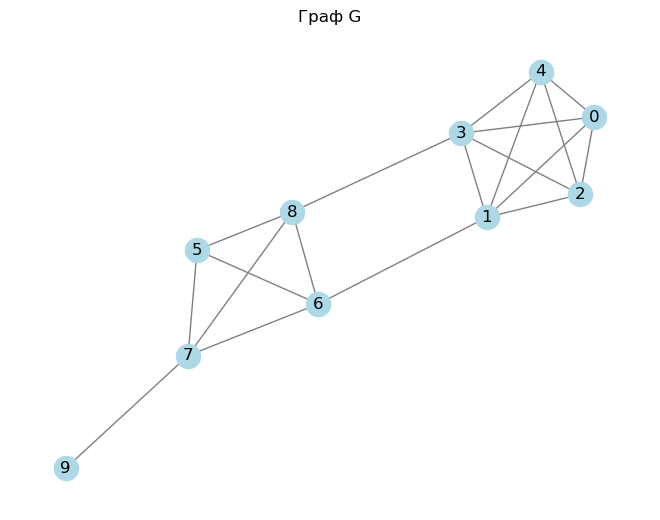

In [9]:
# --- Визуализация графа (как в задании) ---
pos = nx.spring_layout(G, seed=30)
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Граф G")
plt.show()

In [10]:
# --- Проверка ребер, пересекающих разрезы (для самоконтроля) ---
print("\nРебра графа G:", list(G.edges()))

print("\nПроверка ребер для C1:")
crossing_edges_c1 = []
for u, v in G.edges():
    if (u in N1_1 and v in N2_1) or (v in N1_1 and u in N2_1):
        crossing_edges_c1.append((u,v))
print(f"  Ребра, пересекающие C1: {crossing_edges_c1} (Количество: {len(crossing_edges_c1)})") # Должно быть [(8, 3), (6, 1)]

print("\nПроверка ребер для C2:")
crossing_edges_c2 = []
for u, v in G.edges():
     if (u in N1_2 and v in N2_2) or (v in N1_2 and u in N2_2):
         crossing_edges_c2.append((u,v))
print(f"  Ребра, пересекающие C2: {crossing_edges_c2} (Количество: {len(crossing_edges_c2)})") # Должно быть [(7, 9)]


Ребра графа G: [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (1, 6), (2, 3), (2, 4), (3, 4), (3, 8), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8), (7, 9)]

Проверка ребер для C1:
  Ребра, пересекающие C1: [(1, 6), (3, 8)] (Количество: 2)

Проверка ребер для C2:
  Ребра, пересекающие C2: [(7, 9)] (Количество: 1)


<p class="task" id="2"></p>

2\. Для разрезов из предыдущего задания вычислите

$$ Vol(N_t^{(k)}) = \sum_{i \in N_t^{(k)}, j \in N} l_{ij}=\sum_{i \in N_t^{(k)}} k_{i}, t=1,2 $$

$$Q_{normalized}^{(k)}=\frac{cut(N_1^{(k)},N_2^{(k)})}{Vol(N_1^{(k)})}+\frac{cut(N_1^{(k)},N_2^{(k)})}{Vol(N_2^{(k)})}$$
и
$$Q_{quotient}^{(k)}=\frac{cut(N_1^{(k)},N_2^{(k)})}{\min(Vol(N_1^{(k)}),Vol(N_2^{(k)}))}$$

Для каждого разреза выведите четыре величины $Vol(N_1^{(k)})$, $Vol(N_2^{(k)})$, $Q_{normalized}^{(k)}$ и $Q_{quotient}^{(k)}$ на экран.
- [ ] Проверено на семинаре

В предыдущем задание мы уже вичислили cut1_nx и cut2_nx. Оставих их и не будем считать занова 

In [11]:
# Вычисляем Vol(N1_1)
# Vol(S) = сумма степеней всех вершин в множестве S
# В networkx есть удобная функция nx.volume(G, S)
vol1_1 = nx.volume(G, N1_1) # Сумма степеней узлов {0, 1, 2, 3, 4}
print(f"Vol(N1_1) = {vol1_1}")

Vol(N1_1) = 22


In [12]:
# Вычисляем Vol(N2_1)
vol1_2 = nx.volume(G, N2_1) # Сумма степеней узлов {5, 6, 7, 8, 9}
print(f"Vol(N2_1) = {vol1_2}")

Vol(N2_1) = 16


In [13]:
# Вычисляем Q_normalized(1)
# Проверяем, что знаменатели не равны нулю (в данном случае они не будут)
if vol1_1 > 0 and vol1_2 > 0:
    q_norm1 = (cut1_nx / vol1_1) + (cut1_nx / vol1_2)
    print(f"Q_normalized(1) = {q_norm1:.4f}") # Выводим с 4 знаками после запятой
else:
    print("Q_normalized(1) не может быть вычислен (деление на ноль)")

Q_normalized(1) = 0.2159


In [16]:
# Вычисляем Q_quotient(1)
min_vol1 = min(vol1_1, vol1_2)
if min_vol1 > 0:
    q_quot1 = cut1_nx / min_vol1
    print(f"Q_quotient(1) = {q_quot1:.4f}")
else:
    print("Q_quotient(1) не может быть вычислен (деление на ноль)")

Q_quotient(1) = 0.1250


In [17]:
# Вычисляем Vol(N1_2)
vol2_1 = nx.volume(G, N1_2) # Сумма степеней узлов {0, ..., 8}
print(f"Vol(N1_2) = {vol2_1}")

Vol(N1_2) = 37


In [18]:
# Вычисляем Vol(N2_2)
vol2_2 = nx.volume(G, N2_2) # Сумма степеней узла {9}
print(f"Vol(N2_2) = {vol2_2}")

Vol(N2_2) = 1


In [19]:
# Вычисляем Q_normalized(2)
if vol2_1 > 0 and vol2_2 > 0:
    q_norm2 = (cut2_nx / vol2_1) + (cut2_nx / vol2_2)
    print(f"Q_normalized(2) = {q_norm2:.4f}")
else:
    print("Q_normalized(2) не может быть вычислен (деление на ноль)")

# Вычисляем Q_quotient(2)
min_vol2 = min(vol2_1, vol2_2)
if min_vol2 > 0:
    q_quot2 = cut2_nx / min_vol2
    print(f"Q_quotient(2) = {q_quot2:.4f}")
else:
    print("Q_quotient(2) не может быть вычислен (деление на ноль)")

Q_normalized(2) = 1.0270
Q_quotient(2) = 1.0000


<p class="task" id="3"></p>

3\. Для графа `G` из задания 1 вычислите матрицу Лапласа двумя способами:
* по формуле $\mathbf{L}=\mathbf{D}-\mathbf{A}$;
* используя готовую функцию из `networkx`.

Выведите полученные матрицы на экран и покажите, что они равны.

- [x] Проверено на семинаре

In [21]:
# --- Убедимся в фиксированном порядке узлов ---
# Это важно, чтобы строки/столбцы матриц соответствовали одним и тем же узлам
node_list = sorted(list(G.nodes())) # Получаем отсортированный список узлов [0, 1, ..., 9]
n = G.number_of_nodes() # Количество узлов

print(f"Порядок узлов для матриц: {node_list}")

Порядок узлов для матриц: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [23]:
# --- Способ 1: Вычисление по формуле L = D - A ---
# 1. Получаем матрицу смежности A
# nx.adjacency_matrix возвращает разреженную матрицу SciPy, преобразуем ее в плотный массив NumPy
A = nx.adjacency_matrix(G, nodelist=node_list).toarray()
print("Матрица смежности A:")
print(A)


Матрица смежности A:
[[0 1 1 1 1 0 0 0 0 0]
 [1 0 1 1 1 0 1 0 0 0]
 [1 1 0 1 1 0 0 0 0 0]
 [1 1 1 0 1 0 0 0 1 0]
 [1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 0]
 [0 1 0 0 0 1 0 1 1 0]
 [0 0 0 0 0 1 1 0 1 1]
 [0 0 0 1 0 1 1 1 0 0]
 [0 0 0 0 0 0 0 1 0 0]]


In [26]:
# 2. Создаем матрицу степеней D
# Сначала получаем степени всех вершин в нужном порядке
degrees = [G.degree(node) for node in node_list]
# Создаем диагональную матрицу D с помощью NumPy
D = np.diag(degrees)
print("Матрица степеней D:")
print(D)

Матрица степеней D:
[[4 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 0 4 0 0]
 [0 0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0 1]]


In [27]:
# 3. Вычисляем матрицу Лапласа L = D - A
L_manual = D - A
print("Матрица Лапласа L (вычисленная вручную как D - A):")
print(L_manual)

Матрица Лапласа L (вычисленная вручную как D - A):
[[ 4 -1 -1 -1 -1  0  0  0  0  0]
 [-1  5 -1 -1 -1  0 -1  0  0  0]
 [-1 -1  4 -1 -1  0  0  0  0  0]
 [-1 -1 -1  5 -1  0  0  0 -1  0]
 [-1 -1 -1 -1  4  0  0  0  0  0]
 [ 0  0  0  0  0  3 -1 -1 -1  0]
 [ 0 -1  0  0  0 -1  4 -1 -1  0]
 [ 0  0  0  0  0 -1 -1  4 -1 -1]
 [ 0  0  0 -1  0 -1 -1 -1  4  0]
 [ 0  0  0  0  0  0  0 -1  0  1]]


In [28]:
# --- Способ 2: Использование готовой функции networkx ---

# nx.laplacian_matrix также возвращает разреженную матрицу, преобразуем ее
L_nx = nx.laplacian_matrix(G, nodelist=node_list).toarray()
print("Матрица Лапласа L (полученная функцией networkx):")
print(L_nx)

Матрица Лапласа L (полученная функцией networkx):
[[ 4 -1 -1 -1 -1  0  0  0  0  0]
 [-1  5 -1 -1 -1  0 -1  0  0  0]
 [-1 -1  4 -1 -1  0  0  0  0  0]
 [-1 -1 -1  5 -1  0  0  0 -1  0]
 [-1 -1 -1 -1  4  0  0  0  0  0]
 [ 0  0  0  0  0  3 -1 -1 -1  0]
 [ 0 -1  0  0  0 -1  4 -1 -1  0]
 [ 0  0  0  0  0 -1 -1  4 -1 -1]
 [ 0  0  0 -1  0 -1 -1 -1  4  0]
 [ 0  0  0  0  0  0  0 -1  0  1]]


In [29]:
# Используем функцию numpy.array_equal для проверки поэлементного равенства
are_equal = np.array_equal(L_manual, L_nx)
print(f"{are_equal}")

True


<p class="task" id="4"></p>

4\. Для каждого из разрезов первого задания вычислите величины $Q^{(k)}$, воспользовавшись матрицей Лапласа.

$Q^{(k)}={1\over4}z^{(k)T}Lz^{k}$<br>
$z^{k}=[1\space or\space -1]_{1\times N}$


- [ ] Проверено на семинаре

In [32]:
print(f"Матрица Лапласа L (размер \n {L_nx}):")
print(f"Порядок узлов: {node_list}")

Матрица Лапласа L (размер 
 [[ 4 -1 -1 -1 -1  0  0  0  0  0]
 [-1  5 -1 -1 -1  0 -1  0  0  0]
 [-1 -1  4 -1 -1  0  0  0  0  0]
 [-1 -1 -1  5 -1  0  0  0 -1  0]
 [-1 -1 -1 -1  4  0  0  0  0  0]
 [ 0  0  0  0  0  3 -1 -1 -1  0]
 [ 0 -1  0  0  0 -1  4 -1 -1  0]
 [ 0  0  0  0  0 -1 -1  4 -1 -1]
 [ 0  0  0 -1  0 -1 -1 -1  4  0]
 [ 0  0  0  0  0  0  0 -1  0  1]]):
Порядок узлов: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [33]:
# Создаем вектор z1
z1 = np.zeros(n) # Создаем нулевой вектор нужной длины
for i, node in enumerate(node_list): # Идем по узлам в том же порядке, что и в матрице L
    if node in N1_1:
        z1[i] = 1
    elif node in N2_1: # Можно просто else, т.к. узел должен быть в одном из множеств
        z1[i] = -1
    # Если узел не попал ни туда, ни туда (не должно быть для полного разреза), останется 0

print(f"Индикаторный вектор z1 для разреза C1:")
print(z1)

Индикаторный вектор z1 для разреза C1:
[ 1.  1.  1.  1.  1. -1. -1. -1. -1. -1.]


In [35]:
# Вычисляем Q1 по формуле
# Используем оператор @ для матричного умножения в NumPy
# z1.T - транспонирование (хотя для 1D массива в NumPy это часто не обязательно)
Q1_laplacian = (z1.T @ L_nx @ z1) / 4
print(f"\nВеличина разреза Q1, вычисленная через Лапласиан: {Q1_laplacian}")


Величина разреза Q1, вычисленная через Лапласиан: 2.0


In [36]:
# Создаем вектор z2
z2 = np.zeros(n)
for i, node in enumerate(node_list):
    if node in N1_2:
        z2[i] = 1
    elif node in N2_2:
        z2[i] = -1

print(f"Индикаторный вектор z2 для разреза C2:")
print(z2)

Индикаторный вектор z2 для разреза C2:
[ 1.  1.  1.  1.  1.  1.  1.  1.  1. -1.]


In [38]:
Q2_laplacian = (z2.T @ L_nx @ z2) / 4

print(f"\nВеличина разреза Q2, вычисленная через Лапласиан: {Q2_laplacian}")


Величина разреза Q2, вычисленная через Лапласиан: 1.0


In [39]:
cut1_task1 = nx.cut_size(G, N1_1, N2_1)
cut2_task1 = nx.cut_size(G, N1_2, N2_2)

print(f"Сравнение с Заданием 1:")
print(f"  Q1 (Лапласиан): {Q1_laplacian}, Q1 (явный подсчет): {cut1_task1}")
print(f"  Q2 (Лапласиан): {Q2_laplacian}, Q2 (явный подсчет): {cut2_task1}")
print(f"  Равенство для Q1: {np.isclose(Q1_laplacian, cut1_task1)}") # Используем isclose для сравнения float
print(f"  Равенство для Q2: {np.isclose(Q2_laplacian, cut2_task1)}")

Сравнение с Заданием 1:
  Q1 (Лапласиан): 2.0, Q1 (явный подсчет): 2
  Q2 (Лапласиан): 1.0, Q2 (явный подсчет): 1
  Равенство для Q1: True
  Равенство для Q2: True


<p class="task" id="5"></p>

5\. Найдите собственные значения и собственные векторы матрицы Лапласа. Выведите на экран кратность нулевого собственного значения матрицы Лапласа. Найдите и выведите на экран количество компонент связности в графе `G`.

Создайте копию графа `G` с удаленными ребрами в соответствии с разрезом $C^{(1)}$. Повторите решение задачи для получившегося несвязного графа.

- [ ] Проверено на семинаре

In [40]:
# 1. Находим собственные значения и векторы
# Используем np.linalg.eigh, т.к. Лапласиан - симметричная матрица.
# Она возвращает собственные значения в порядке возрастания.
eigenvalues, eigenvectors = np.linalg.eigh(L_nx)

print(f"Собственные значения матрицы Лапласа L (первые несколько):")
print(eigenvalues[:5])

Собственные значения матрицы Лапласа L (первые несколько):
[-5.06539440e-16  5.04061481e-01  1.24963007e+00  4.20366298e+00
  4.38196601e+00]


In [41]:
# 2. Находим кратность нулевого собственного значения
# Из-за погрешностей вычислений, "нулевые" значения могут быть очень маленькими числами
# Используем np.isclose для проверки близости к нулю
zero_eigenvalue_multiplicity = np.sum(np.isclose(eigenvalues, 0, atol=1e-8)) # atol - абсолютный допуск
print(f"\nКратность нулевого собственного значения L: {zero_eigenvalue_multiplicity}")


Кратность нулевого собственного значения L: 1


In [42]:
# 3. Находим количество компонент связности графа G
num_connected_components = nx.number_connected_components(G)
print(f"Количество компонент связности графа G (из networkx): {num_connected_components}")

Количество компонент связности графа G (из networkx): 1


In [43]:
# Проверяем теорему: кратность нулевого с.з. должна быть равна числу компонент связности
print(f"Совпадают ли кратность и число компонент? {zero_eigenvalue_multiplicity == num_connected_components}")

Совпадают ли кратность и число компонент? True


In [44]:
# --- Анализ графа G после удаления ребер разреза C1 ---

# 1. Определяем разрез C1 и ребра, его пересекающие
N1_1 = {0, 1, 2, 3, 4}
N2_1 = {5, 6, 7, 8, 9}
edges_to_remove = []
for u, v in G.edges():
    if (u in N1_1 and v in N2_1) or (v in N1_1 and u in N2_1):
        edges_to_remove.append((u, v))

print(f"Разрез C1: N1={N1_1}, N2={N2_1}")
print(f"Ребра, пересекающие разрез C1 (будут удалены): {edges_to_remove}") 

Разрез C1: N1={0, 1, 2, 3, 4}, N2={5, 6, 7, 8, 9}
Ребра, пересекающие разрез C1 (будут удалены): [(1, 6), (3, 8)]


In [45]:
# 2. Создаем копию графа и удаляем ребра
G_disconnected = G.copy()
G_disconnected.remove_edges_from(edges_to_remove)

In [46]:
# 3. Вычисляем Лапласиан для нового графа G_disconnected
L_disconnected = nx.laplacian_matrix(G_disconnected, nodelist=node_list).toarray()

In [47]:
# 4. Находим собственные значения и векторы для L_disconnected
eigenvalues_dc, eigenvectors_dc = np.linalg.eigh(L_disconnected)

In [48]:
print(f"\nСобственные значения матрицы Лапласа L_disconnected (первые несколько):")
print(eigenvalues_dc[:5])


Собственные значения матрицы Лапласа L_disconnected (первые несколько):
[-5.55111512e-16 -2.22044605e-16  1.00000000e+00  4.00000000e+00
  4.00000000e+00]


In [49]:
# 5. Находим кратность нулевого собственного значения для L_disconnected
zero_eigenvalue_multiplicity_dc = np.sum(np.isclose(eigenvalues_dc, 0, atol=1e-8))
print(f"\nКратность нулевого собственного значения L_disconnected: {zero_eigenvalue_multiplicity_dc}")


Кратность нулевого собственного значения L_disconnected: 2


In [50]:
# 6. Находим количество компонент связности графа G_disconnected
num_connected_components_dc = nx.number_connected_components(G_disconnected)
print(f"Количество компонент связности графа G_disconnected (из networkx): {num_connected_components_dc}")

Количество компонент связности графа G_disconnected (из networkx): 2


In [51]:
# Проверяем теорему для нового графа
print(f"Совпадают ли кратность и число компонент? {zero_eigenvalue_multiplicity_dc == num_connected_components_dc}")

Совпадают ли кратность и число компонент? True


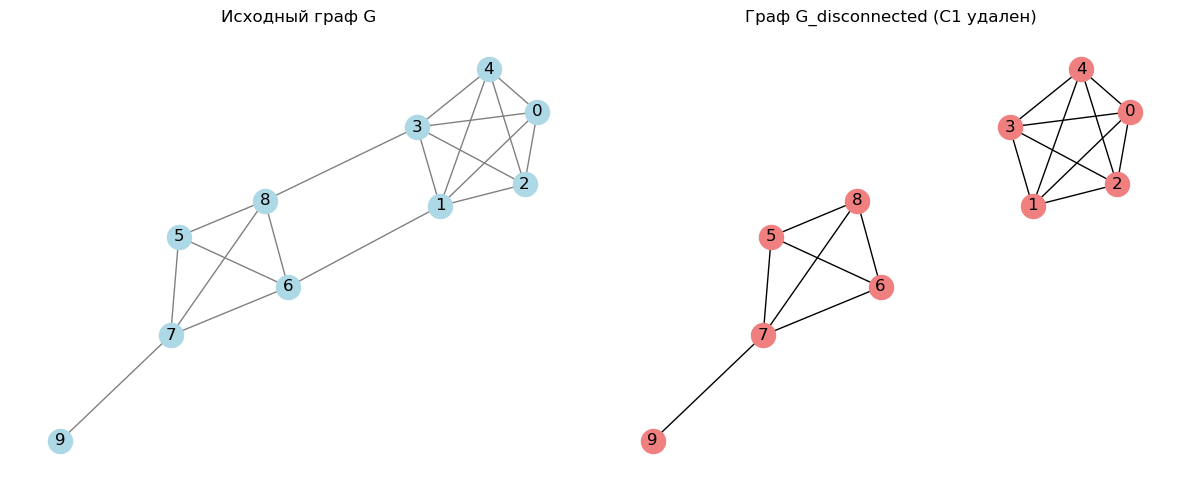

In [52]:
# --- Визуализация (опционально) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pos = nx.spring_layout(G, seed=30)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Исходный граф G")

plt.subplot(1, 2, 2)
# Используем то же расположение узлов для наглядности
nx.draw(G_disconnected, pos, with_labels=True, node_color='lightcoral')
plt.title("Граф G_disconnected (C1 удален)")

plt.tight_layout()
plt.show()
